#  Student Mental Health Analysis
**Dataset:** Student Mental Health Survey | **n = 101 students**

---

We start by importing Various Libraries neccesary for Data Analytics 

1. For Columns that have yes and No answers , We Represent Yes with 1 and No with 0 
2. For The Year, Some are saved as "Year " and others as "year" so we are to carry out the normalization of this values 


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np

# Load dataset
df = pd.read_csv("Student Mental health.csv")


yn_cols = [
    'Do you have Depression?',
    'Do you have Anxiety?',
    'Do you have Panic attack?',
    'Did you seek any specialist for a treatment?',
    'Marital status',
]
for col in yn_cols:
    df[col + '_bin'] = df[col].map({'Yes': 1, 'No': 0})


df['Year'] = df['Your current year of Study'].str.strip().str.title()
df['CGPA_clean'] = df['What is your CGPA?'].str.strip()

# Condition count per student
df['condition_count'] = (
    df['Do you have Depression?_bin'] +
    df['Do you have Anxiety?_bin'] +
    df['Do you have Panic attack?_bin']
)

print("✅ Data loaded successfully")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

✅ Data loaded successfully
   Shape: 101 rows × 19 columns


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?,Do you have Depression?_bin,Do you have Anxiety?_bin,Do you have Panic attack?_bin,Did you seek any specialist for a treatment?_bin,Marital status_bin,Year,CGPA_clean,condition_count
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,1,0,1,0,0,Year 1,3.00 - 3.49,2
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No,0,1,0,0,0,Year 2,3.00 - 3.49,1
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,1,1,1,0,0,Year 1,3.00 - 3.49,3
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,1,0,0,0,1,Year 3,3.00 - 3.49,1
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No,0,0,0,0,0,Year 4,3.00 - 3.49,0


##  Key Metrics Summary
The key Metric Includes the count for female and Male , The gender , the depression , Anxiety and Panic attack rate 

In [ ]:
affected = df[df['condition_count'] > 0]

summary = {
    'Total Respondents': len(df),
    'Female': (df['Choose your gender'] == 'Female').sum(),
    'Male': (df['Choose your gender'] == 'Male').sum(),
    'Age (Mean)': round(df['Age'].mean(), 1),
    'Age Range': f"{int(df['Age'].min())}–{int(df['Age'].max())}",
    'Depression Rate': f"{df['Do you have Depression?_bin'].mean()*100:.1f}%",
    'Anxiety Rate': f"{df['Do you have Anxiety?_bin'].mean()*100:.1f}%",
    'Panic Attack Rate': f"{df['Do you have Panic attack?_bin'].mean()*100:.1f}%",
    'Sought Treatment (overall)': f"{df['Did you seek any specialist for a treatment?_bin'].mean()*100:.1f}%",
    'Students with ≥1 Condition': f"{len(affected)} ({len(affected)/len(df)*100:.1f}%)",
    'Treatment Rate (among affected)': f"{affected['Did you seek any specialist for a treatment?_bin'].mean()*100:.1f}%",
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Metric,Value
Total Respondents,101
Female,75
Male,26
Age (Mean),20.500000
Age Range,18–24
Depression Rate,34.7%
Anxiety Rate,33.7%
Panic Attack Rate,32.7%
Sought Treatment (overall),5.9%
Students with ≥1 Condition,64 (63.4%)


##  Dashboard — All Key Metrics

We use all the key metrics to create a dashboard

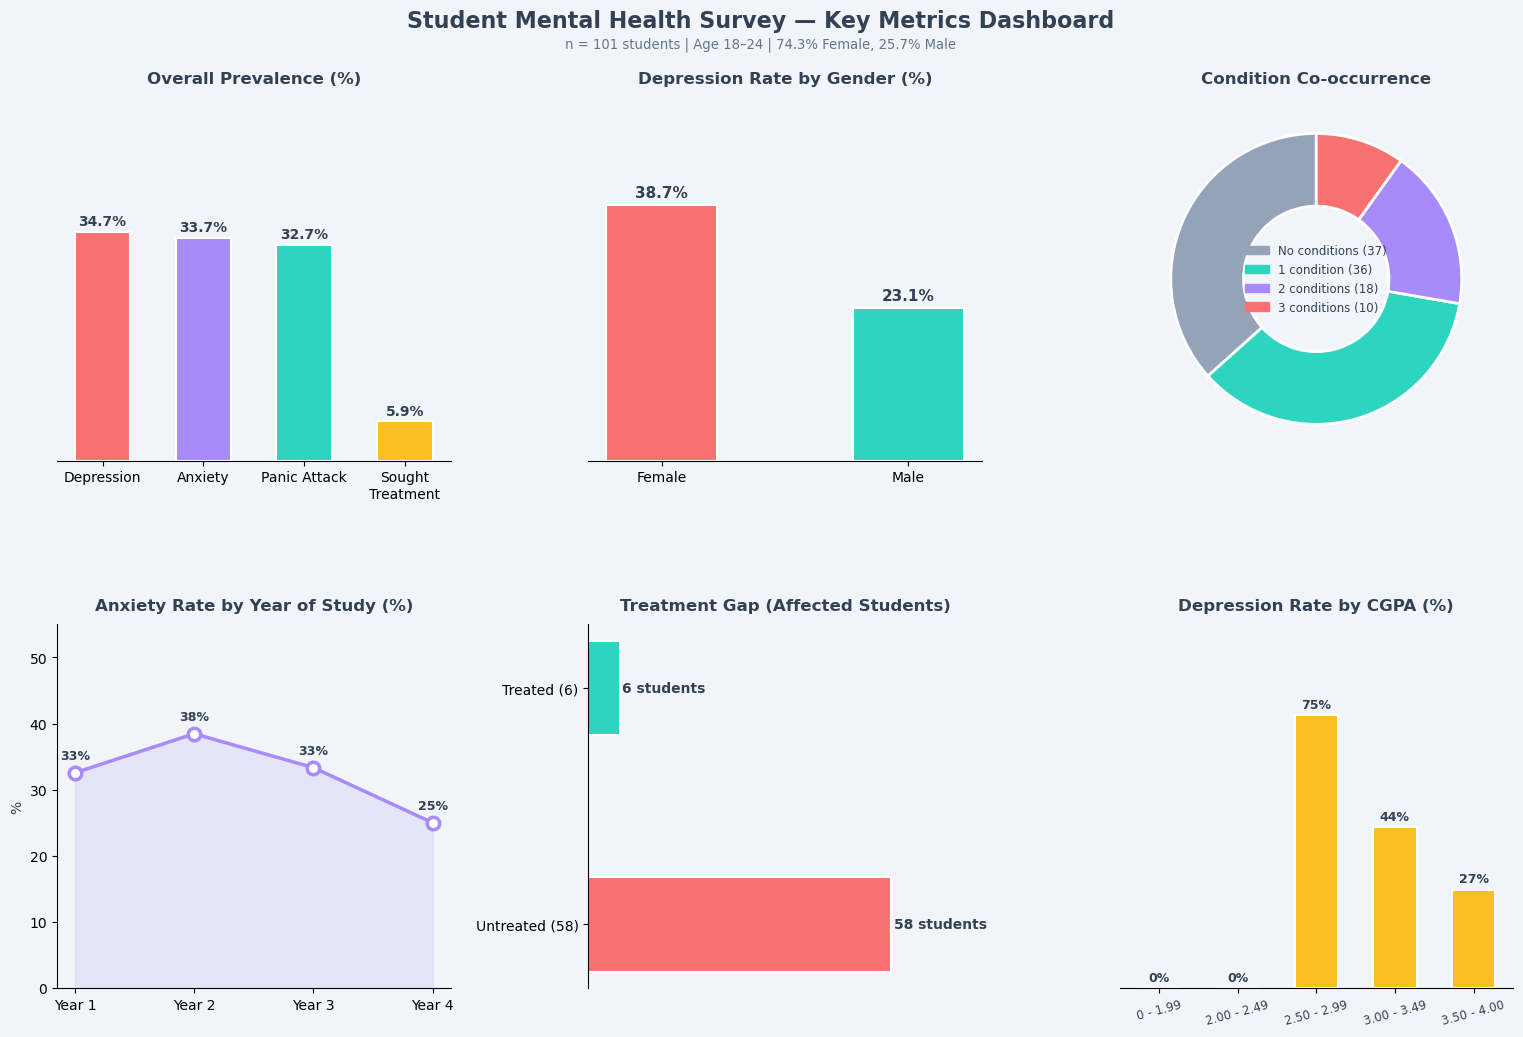

In [ ]:
TEAL   = '#2DD4BF'
CORAL  = "#EA7676"
PURPLE = '#A78BFA'
AMBER  = '#FBBF24'
SLATE  = '#334155'
LIGHT  = '#F1F5F9'

fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor(LIGHT)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.88, bottom=0.07)

# 1. Overall prevalence
ax1   = fig.add_subplot(gs[0, 0])
cats  = ['Depression', 'Anxiety', 'Panic Attack', 'Sought\nTreatment']
vals  = [
    df['Do you have Depression?_bin'].mean() * 100,
    df['Do you have Anxiety?_bin'].mean() * 100,
    df['Do you have Panic attack?_bin'].mean() * 100,
    df['Did you seek any specialist for a treatment?_bin'].mean() * 100,
]
colors = [CORAL, PURPLE, TEAL, AMBER]
bars   = ax1.bar(cats, vals, color=colors, width=0.55, edgecolor='white', linewidth=1.5)
ax1.set_ylim(0, 55)
ax1.set_title('Overall Prevalence (%)', fontsize=12, fontweight='bold', color=SLATE, pad=10)
ax1.set_facecolor(LIGHT); ax1.spines[['top','right','left']].set_visible(False); ax1.yaxis.set_visible(False)
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color=SLATE)

# 2. Depression by gender
ax2      = fig.add_subplot(gs[0, 1])
gender_d = df.groupby('Choose your gender')['Do you have Depression?_bin'].mean() * 100
genders  = gender_d.index.tolist()
g_colors = [CORAL if g == 'Female' else TEAL for g in genders]
bars2    = ax2.bar(genders, gender_d.values, color=g_colors, width=0.45, edgecolor='white', linewidth=1.5)
ax2.set_title('Depression Rate by Gender (%)', fontsize=12, fontweight='bold', color=SLATE, pad=10)
ax2.set_facecolor(LIGHT); ax2.spines[['top','right','left']].set_visible(False); ax2.yaxis.set_visible(False); ax2.set_ylim(0, 55)
for bar, val in zip(bars2, gender_d.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1.2, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color=SLATE)

# 3. Co-occurrence donut
ax3      = fig.add_subplot(gs[0, 2])
sizes_d  = [(df['condition_count'] == i).sum() for i in range(4)]
labels_d = ['No conditions', '1 condition', '2 conditions', '3 conditions']
pie_colors = ['#94A3B8', TEAL, PURPLE, CORAL]
ax3.pie(sizes_d, labels=None, colors=pie_colors, startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))
ax3.set_title('Condition Co-occurrence', fontsize=12, fontweight='bold', color=SLATE, pad=10)
patches = [mpatches.Patch(color=c, label=f'{l} ({s})') for c, l, s in zip(pie_colors, labels_d, sizes_d)]
ax3.legend(handles=patches, loc='center', fontsize=8.5, frameon=False, labelcolor=SLATE)

# 4. Anxiety by year
ax4        = fig.add_subplot(gs[1, 0])
year_order = ['Year 1', 'Year 2', 'Year 3', 'Year 4']
anxiety_yr = df.groupby('Year')['Do you have Anxiety?_bin'].mean() * 100
anxiety_yr = anxiety_yr.reindex([y for y in year_order if y in anxiety_yr.index])
ax4.plot(anxiety_yr.index, anxiety_yr.values, marker='o', color=PURPLE, linewidth=2.5,
         markersize=9, markerfacecolor='white', markeredgewidth=2.5)
ax4.fill_between(anxiety_yr.index, anxiety_yr.values, alpha=0.15, color=PURPLE)
ax4.set_title('Anxiety Rate by Year of Study (%)', fontsize=12, fontweight='bold', color=SLATE, pad=10)
ax4.set_facecolor(LIGHT); ax4.spines[['top','right']].set_visible(False); ax4.set_ylim(0, 55)
ax4.set_ylabel('%', color=SLATE, fontsize=10)
for x, y in zip(anxiety_yr.index, anxiety_yr.values):
    ax4.annotate(f'{y:.0f}%', (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color=SLATE)

# 5. Treatment gap
ax5         = fig.add_subplot(gs[1, 1])
affected_n  = len(df[df['condition_count'] > 0])
treated_n   = int(df['Did you seek any specialist for a treatment?_bin'].sum())
untreated_n = affected_n - treated_n
bars5 = ax5.barh([f'Untreated ({untreated_n})', f'Treated ({treated_n})'],
                 [untreated_n, treated_n], color=[CORAL, TEAL], height=0.4, edgecolor='white', linewidth=1.5)
ax5.set_title('Treatment Gap (Affected Students)', fontsize=12, fontweight='bold', color=SLATE, pad=10)
ax5.set_facecolor(LIGHT); ax5.spines[['top','right','bottom']].set_visible(False); ax5.xaxis.set_visible(False)
for bar, val in zip(bars5, [untreated_n, treated_n]):
    ax5.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val} students', va='center', fontsize=10, fontweight='bold', color=SLATE)
ax5.set_xlim(0, max(untreated_n, treated_n) * 1.3)

# 6. CGPA vs Depression
ax6        = fig.add_subplot(gs[1, 2])
cgpa_order = ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']
cgpa_dep   = df.groupby('CGPA_clean')['Do you have Depression?_bin'].mean() * 100
cgpa_dep   = cgpa_dep.reindex([c for c in cgpa_order if c in cgpa_dep.index])
ax6.bar(range(len(cgpa_dep)), cgpa_dep.values, color=AMBER, width=0.55, edgecolor='white', linewidth=1.5)
ax6.set_title('Depression Rate by CGPA (%)', fontsize=12, fontweight='bold', color=SLATE, pad=10)
ax6.set_facecolor(LIGHT); ax6.spines[['top','right','left']].set_visible(False); ax6.yaxis.set_visible(False)
ax6.set_xticks(range(len(cgpa_dep))); ax6.set_xticklabels(cgpa_dep.index, rotation=15, fontsize=8.5, color=SLATE); ax6.set_ylim(0, 100)
for i, val in enumerate(cgpa_dep.values):
    ax6.text(i, val + 2, f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold', color=SLATE)

fig.suptitle('Student Mental Health Survey — Key Metrics Dashboard', fontsize=16, fontweight='bold', color=SLATE, y=0.96)
fig.text(0.5, 0.925, f'n = {len(df)} students | Age {int(df["Age"].min())}–{int(df["Age"].max())} | 74.3% Female, 25.7% Male',
         ha='center', fontsize=9.5, color='#64748B')
plt.show()

### 1. Mental health rates by gender

In [4]:
gender_mh = df.groupby('Choose your gender')[
    ['Do you have Depression?_bin', 'Do you have Anxiety?_bin', 'Do you have Panic attack?_bin']
].mean() * 100
gender_mh.columns = ['Depression %', 'Anxiety %', 'Panic Attack %']
gender_mh.round(1)

,Depression %,Anxiety %,Panic Attack %
Choose your gender,,,
Female,38.7,32.0,33.3
Male,23.1,38.5,30.8


### 2. Condition rates by year of study

In [5]:
year_mh = df.groupby('Year')[
    ['Do you have Depression?_bin', 'Do you have Anxiety?_bin', 'Do you have Panic attack?_bin']
].mean() * 100
year_mh.columns = ['Depression %', 'Anxiety %', 'Panic Attack %']
year_order = ['Year 1', 'Year 2', 'Year 3', 'Year 4']
year_mh.reindex([y for y in year_order if y in year_mh.index]).round(1)

,Depression %,Anxiety %,Panic Attack %
Year,,,
Year 1,32.6,32.6,32.6
Year 2,38.5,38.5,30.8
Year 3,41.7,33.3,41.7
Year 4,12.5,25.0,12.5


### 3. Depression rate by CGPA band

In [6]:
cgpa_order = ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']
cgpa_summary = df.groupby('CGPA_clean').agg(
    Count=('CGPA_clean', 'count'),
    Depression_pct=('Do you have Depression?_bin', lambda x: round(x.mean()*100, 1)),
    Anxiety_pct=('Do you have Anxiety?_bin', lambda x: round(x.mean()*100, 1)),
).reindex([c for c in cgpa_order if c in df['CGPA_clean'].unique()])
cgpa_summary.columns = ['Count', 'Depression %', 'Anxiety %']
cgpa_summary

,Count,Depression %,Anxiety %
CGPA_clean,,,
0 - 1.99,4,0.0,0.0
2.00 - 2.49,2,0.0,0.0
2.50 - 2.99,4,75.0,25.0
3.00 - 3.49,43,44.2,34.9
3.50 - 4.00,48,27.1,37.5


### 4. Co-occurrence breakdown

In [7]:
co = df['condition_count'].value_counts().sort_index().reset_index()
co.columns = ['Number of Conditions', 'Student Count']
co['% of Total'] = (co['Student Count'] / len(df) * 100).round(1)
co

,Number of Conditions,Student Count,% of Total
0,0,37,36.6
1,1,36,35.6
2,2,18,17.8
3,3,10,9.9



##  Key Insights

 Insight 

 1 | **63.4%** of students reported at least one mental health condition |
 2 | Only **9.4%** of affected students sought professional help — a critical treatment gap |
 3 | Women report depression at nearly **twice the rate** of men (39% vs 23%) |
 4 | Anxiety **peaks in Year 2** (38%) then declines — the post-Year-1 transition appears most stressful |
 5 | Mid-CGPA students (2.50–3.49) show the **highest depression rates** |
 6 | **28 students** reported 2 or 3 co-occurring conditions simultaneously |

